# 👥 Customer Segmentation Tool

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/analytics-accelerator/customer-segments/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=analytics-accelerator/customer-segments/demo.ipynb)

> **Pain point:** *We don't know who our customer groups are.*

Feed in a customer table and KMeans surfaces the natural groups hiding in the behavior — then the tool auto-picks how many segments there are, names each one, and shows how distinct they really are. No guesswork, no hand-drawn buckets.

**What this notebook covers**
1. The core logic — scale, auto-k, cluster, profile
2. A sample customer base (300 customers, 3 hidden groups)
3. Letting silhouette pick the number of segments
4. Named segment profiles
5. A segment map you could drop straight into a deck


## Step 1 — The core logic

Segmentation in four moves: **standardize** the features (so spend in dollars and frequency in counts are comparable), **pick k** by the best silhouette score, **cluster** with KMeans, then **profile** each cluster into a human-readable name like *High-value loyalists* or *At-risk / lapsing*. Pure scikit-learn — no API keys.

In [1]:
from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from segments import sample_customers, segment_customers, select_numeric_features

sns.set_theme(style='whitegrid')
print('Core logic loaded.')

Core logic loaded.


## Step 2 — A sample customer base

`sample_customers()` returns a deterministic 300-row base (seed=42) built from three latent groups — loyalists, mainstream, and lapsing — so the notebook is reproducible and the clustering has something real to recover.

In [2]:
df = sample_customers()
print(f'{len(df)} customers')
df.head()

300 customers


,customer_id,recency_days,frequency,monetary_spend,tenure_months
0,1203,58,6,362.32,13
1,1266,173,1,43.20,4
2,1152,34,9,337.94,13
3,1009,7,19,1101.06,36
4,1233,219,2,77.74,5


The tool auto-selects the numeric behavioral columns and ignores ID-like ones (so `customer_id` never gets clustered as if it were behavior):

In [3]:
print('Features used:', select_numeric_features(df))

Features used: ['recency_days', 'frequency', 'monetary_spend', 'tenure_months']


## Step 3 — Let silhouette pick the number of segments

Rather than guessing k, the tool scores k = 2…8 by silhouette (cluster tightness vs separation) and keeps the best.

In [4]:
res = segment_customers(df)  # n_clusters=None -> auto
print(f'Chosen k = {res.k}  (silhouette = {res.silhouette})')
print('Silhouette by k:')
for k, s in sorted(res.auto_k_scores.items()):
    bar = '#' * int(s * 40)
    print(f'  k={k}: {s:.3f}  {bar}')

Chosen k = 3  (silhouette = 0.726)
Silhouette by k:
  k=2: 0.657  ##########################
  k=3: 0.726  #############################
  k=4: 0.562  ######################
  k=5: 0.452  ##################
  k=6: 0.431  #################
  k=7: 0.310  ############
  k=8: 0.289  ###########


## Step 4 — Named segment profiles

Each cluster gets a name and an average-behavior profile — the part a stakeholder actually reads.

In [5]:
prof = pd.DataFrame([
    {'Segment': p.name, 'Customers': p.size, 'Share %': p.share_pct, **p.means}
    for p in res.profiles
])
prof

,Segment,Customers,Share %,recency_days,frequency,monetary_spend,tenure_months
0,Mainstream / mid-tier,135,45.0,53.25,7.43,402.76,11.22
1,High-value loyalists,75,25.0,7.35,21.17,1202.01,32.41
2,At-risk / lapsing,90,30.0,190.96,1.18,67.10,3.51


## Step 5 — The segment map

Two charts: which segments exist and how big they are, plus a 2-D scatter showing the groups separating in the data.

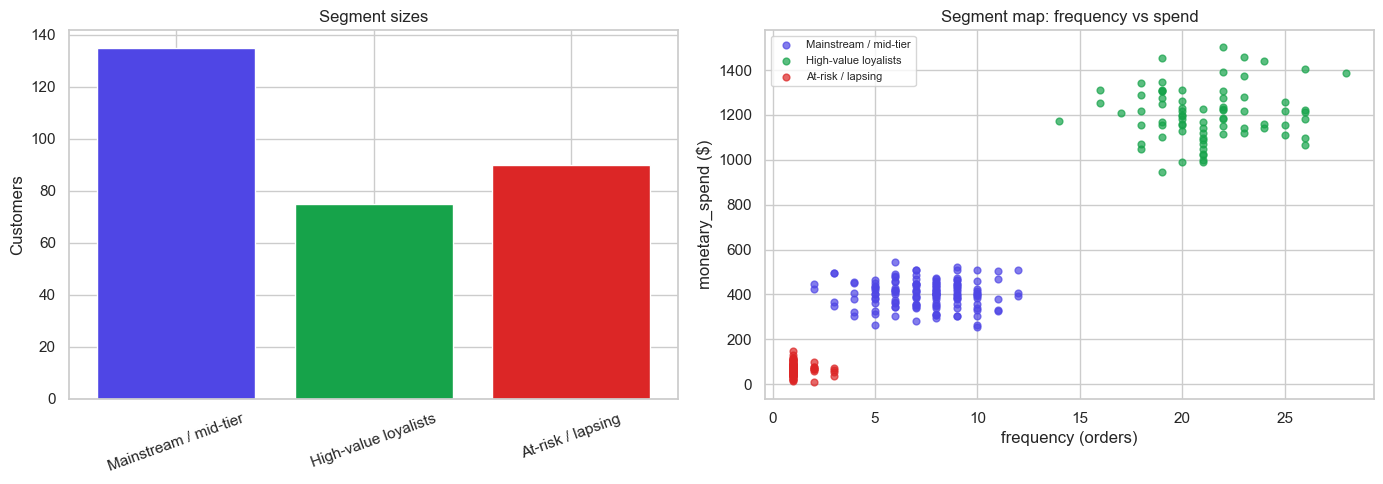

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Segment sizes
names = [p.name for p in res.profiles]
sizes = [p.size for p in res.profiles]
palette = ['#4F46E5', '#16A34A', '#DC2626', '#F59E0B', '#0EA5E9']
colors = [palette[p.label % len(palette)] for p in res.profiles]
axes[0].bar(names, sizes, color=colors)
axes[0].set_title('Segment sizes')
axes[0].set_ylabel('Customers')
axes[0].tick_params(axis='x', rotation=20)

# Scatter: frequency vs spend
for p in res.profiles:
    mask = res.labels == p.label
    axes[1].scatter(df['frequency'][mask], df['monetary_spend'][mask],
                    s=24, alpha=0.7,
                    color=palette[p.label % len(palette)], label=p.name)
axes[1].set_xlabel('frequency (orders)')
axes[1].set_ylabel('monetary_spend ($)')
axes[1].set_title('Segment map: frequency vs spend')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('segments.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

The tool recovered the three latent groups it was given — **loyalists**, **mainstream**, and **lapsing** — picked k on its own, and labeled each with an average-behavior profile. What used to be a workshop full of sticky notes is now one function call you can re-run whenever the data refreshes.

## 🔧 Try your own

Uncomment and point it at your own customer export:

In [7]:
# import pandas as pd
# my_df = pd.read_csv('your_customers.csv')
# my_res = segment_customers(my_df)            # or n_clusters=4 to force k
# print('Segments:', my_res.k, '| silhouette:', my_res.silhouette)
# for p in my_res.profiles:
#     print(p.name, p.size, p.means)

---
Part of **[phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder)** — Day 25 of the 60-day FDE portfolio.

**Run the Streamlit version:**
```bash
pip install -r requirements.txt
streamlit run app.py
```